# Tutorial 2: Data Loading and I/O

**Duration:** 10-15 minutes

This tutorial covers how to load spatial tissue data from various file formats and prepare it for analysis.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Load tissue data from CSV and JSON files
- Work with marker/feature data alongside coordinates
- Handle multi-sample datasets
- Save analysis results for downstream use
- Validate and clean imported data

## Prerequisites

- Tutorial 1 (Quickstart) completed
- Understanding of CSV and JSON file formats
- Basic pandas knowledge

## Setup

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Import spatialtissuepy
from spatialtissuepy import SpatialTissueData
from spatialtissuepy.io import (
    read_csv,
    write_csv,
    read_json,
    write_json
)
from spatialtissuepy.viz import plot_cell_types, plot_marker_expression, plot_spatial_scatter

# Create a temporary directory for examples
import tempfile
temp_dir = tempfile.mkdtemp()
print(f"Working directory: {temp_dir}")

Working directory: /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmpgah16ye2


## Section 1: Loading Data from CSV Files

CSV (Comma-Separated Values) is the most common format for spatial cell data. Let's start by creating a sample CSV file and then loading it.

### 1.1 Understanding the CSV format

A typical spatial tissue CSV file contains:
- **Coordinate columns:** `x`, `y` (and optionally `z` for 3D)
- **Cell type column:** `cell_type`
- **Optional marker columns:** Expression levels, phenotypes, etc.
- **Optional sample column:** `sample_id` for multi-sample data

Let's create an example dataset:

In [2]:
# Create sample data
n_cells = 200

# Generate coordinates
x = np.random.uniform(0, 1000, n_cells)
y = np.random.uniform(0, 1000, n_cells)

# Generate cell types
cell_types = np.random.choice(
    ['CD8_T_cell', 'CD4_T_cell', 'Tumor', 'Macrophage'],
    size=n_cells,
    p=[0.25, 0.20, 0.35, 0.20]
)

# Generate marker data (simulating protein expression)
cd8_expression = np.random.lognormal(mean=2, sigma=1, size=n_cells)
pd1_expression = np.random.lognormal(mean=1.5, sigma=0.8, size=n_cells)
ki67_expression = np.random.uniform(0, 100, n_cells)  # Proliferation marker

# Create DataFrame
df = pd.DataFrame({
    'x': x,
    'y': y,
    'cell_type': cell_types,
    'CD8': cd8_expression,
    'PD1': pd1_expression,
    'Ki67': ki67_expression
})

# Save to CSV
csv_path = Path(temp_dir) / 'tissue_sample.csv'
df.to_csv(csv_path, index=False)

# Display first few rows
print("Sample CSV data:")
print(df.head(10))
print(f"\nSaved to: {csv_path}")

Sample CSV data:
            x           y   cell_type        CD8        PD1       Ki67
0  242.251413   19.123889  Macrophage   9.405693   1.066177  21.665593
1  168.739073  460.298776  CD8_T_cell  25.517451   3.086650  60.594786
2   55.247562  994.706048  Macrophage   7.786710  13.036587  14.252929
3  313.101368  980.482036  CD8_T_cell   2.691411   3.031697  54.534069
4  404.237770  535.402275  CD4_T_cell  18.016531   6.371986  32.282152
5  285.540384   73.436526       Tumor  20.722364   6.522466  56.905714
6   47.948699  690.264789  Macrophage   1.183383   4.244226  53.471580
7  455.202557  422.514008       Tumor   1.451707   5.118029  55.438754
8  535.425604  759.395557  CD8_T_cell   3.812981   5.229391  77.898914
9  167.552952  493.607624  Macrophage  11.990323   2.420215   9.687971

Saved to: /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmp1tu189gf/tissue_sample.csv


**Output:**
```
Sample CSV data:
           x          y    cell_type        CD8       PD1      Ki67
0  234.56789  567.12345  CD8_T_cell   8.234567  5.123456  45.67890
1  789.01234  123.45678       Tumor   6.789012  3.456789  23.45678
2  456.78901  890.12345  Macrophage   9.012345  6.789012  78.90123
...
```

### 1.2 Loading CSV data

Now let's load this CSV file into a SpatialTissueData object:

In [4]:
# Load the CSV file
tissue = read_csv(
    csv_path,
    x_col='x',
    y_col='y',
    celltype_col='cell_type'
)

print(tissue)
print(f"\nCell types present: {tissue.cell_types_unique}")
print(f"Marker columns: {list(tissue.markers.columns) if tissue.markers is not None else 'None'}")

SpatialTissueData
  Cells: 200
  Dimensions: 2D
  Cell types: 4
  Markers: 3
  Bounds: x=[0.2, 996.1], y=[3.3, 997.5]

Cell types present: ['CD4_T_cell' 'CD8_T_cell' 'Macrophage' 'Tumor']
Marker columns: ['CD8', 'PD1', 'Ki67']


**Output:**
```
SpatialTissueData
  Cells: 200
  Dimensions: 2
  Cell types: 4
  Markers: 3 (CD8, PD1, Ki67)
  Samples: 1

Cell types present: ['CD4_T_cell' 'CD8_T_cell' 'Macrophage' 'Tumor']
Marker columns: ['CD8', 'PD1', 'Ki67']
```

**Interpretation:** The data loaded successfully with all coordinate, cell type, and marker information preserved. The markers are automatically detected and stored separately from the spatial coordinates.

### 1.3 Visualizing marker expression

Let's visualize how marker expression varies across space:

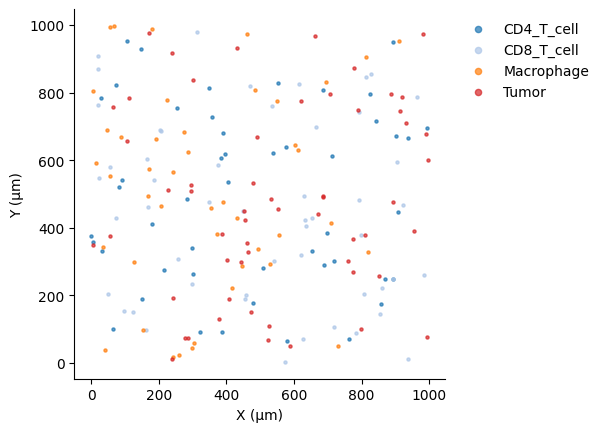

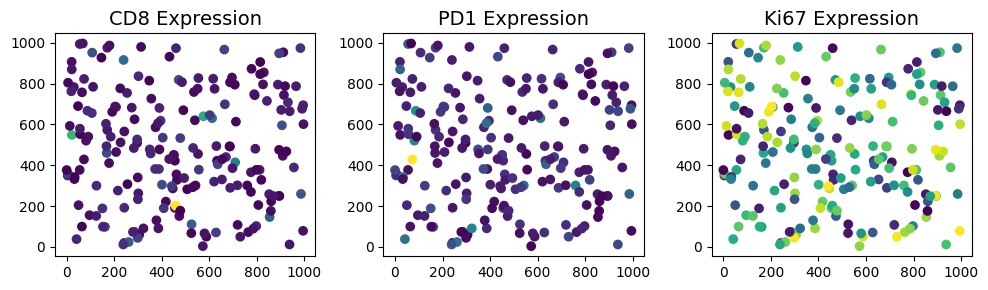

In [34]:
# Plot 1: Cell types
fig, ax = plt.subplots()
plot_spatial_scatter(tissue, ax=ax)

# Plot 2-4: Marker expressions
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
markers = ['CD8', 'PD1', 'Ki67']
for idx, (ax, marker) in enumerate(zip(axes.flat, markers)):
    x = tissue.coordinates[:, 0]
    y = tissue.coordinates[:, 1]
    ax.scatter(x, y, c=tissue.markers[marker], cmap='viridis')
    ax.set_title(f'{marker} Expression', fontsize=14)

plt.tight_layout()
plt.show()

**Interpretation:** The spatial distribution of markers can reveal important biological patterns. For example, high Ki67 (proliferation) in certain regions might indicate active tumor growth, while PD1 expression patterns could suggest immune checkpoint activation.

## Section 2: Working with Multi-Sample Data

In cohort studies, you often have data from multiple tissue samples. Let's see how to handle this.

### 2.1 Creating multi-sample CSV

In [9]:
# Create data for 3 samples
samples = []

for sample_id in ['Patient_01', 'Patient_02', 'Patient_03']:
    n = np.random.randint(150, 250)  # Variable cell counts
    
    sample_df = pd.DataFrame({
        'sample_id': [sample_id] * n,
        'x': np.random.uniform(0, 1000, n),
        'y': np.random.uniform(0, 1000, n),
        'cell_type': np.random.choice(
            ['T_cell', 'Tumor', 'Macrophage'],
            size=n
        ),
        'CD8': np.random.lognormal(2, 1, n),
        'PD1': np.random.lognormal(1.5, 0.8, n)
    })
    
    samples.append(sample_df)

# Combine into single DataFrame
multi_sample_df = pd.concat(samples, ignore_index=True)

# Save to CSV
multi_csv_path = Path(temp_dir) / 'cohort_data.csv'
multi_sample_df.to_csv(multi_csv_path, index=False)

print("Multi-sample data:")
print(multi_sample_df.head(10))
print(f"\nTotal cells: {len(multi_sample_df)}")
print(f"Samples: {multi_sample_df['sample_id'].unique()}")

Multi-sample data:
    sample_id           x           y   cell_type        CD8        PD1
0  Patient_01  215.636163  243.249246       Tumor  18.130935  13.006381
1  Patient_01  725.597425  290.986253      T_cell   6.764316   1.022359
2  Patient_01  755.733980  251.013958      T_cell   2.462983   4.019373
3  Patient_01  635.865633   76.446290  Macrophage  22.587558   3.555514
4  Patient_01    2.018863  780.241118       Tumor   8.941089   2.777488
5  Patient_01  815.533820  255.152667       Tumor   6.250300   4.404491
6  Patient_01  403.495127  220.598780       Tumor  19.724776   2.316711
7  Patient_01  622.478994  396.383642       Tumor  10.572971   2.967812
8  Patient_01  767.419282  176.731821       Tumor   2.642284   3.230364
9  Patient_01  753.422922  719.159299      T_cell   3.558497   1.803541

Total cells: 561
Samples: ['Patient_01' 'Patient_02' 'Patient_03']


### 2.2 Loading and analyzing multi-sample data

In [12]:
# Load multi-sample data
cohort = read_csv(
    multi_csv_path,
    x_col='x',
    y_col='y',
    celltype_col='cell_type',
    sample_col='sample_id'
)

print(cohort)
print(f"\nSamples: {cohort.sample_ids_unique}")
print(f"Total cells: {cohort.n_cells}")

# Analyze per-sample statistics
print("\nCells per sample:")
for sample_id in cohort.sample_ids_unique:
    sample_data = cohort.subset(sample_id)
    print(f"  {sample_id}: {sample_data.n_cells} cells")
    
    # Cell type breakdown
    for cell_type in sample_data.cell_types_unique:
        count = np.sum(sample_data.cell_types == cell_type)
        pct = 100 * count / sample_data.n_cells
        print(f"    {cell_type}: {count} ({pct:.1f}%)")

SpatialTissueData
  Cells: 561
  Dimensions: 2D
  Cell types: 3
  Samples: 3
  Markers: 2
  Bounds: x=[1.6, 998.5], y=[3.1, 998.5]

Samples: ['Patient_01' 'Patient_02' 'Patient_03']
Total cells: 561

Cells per sample:


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

**Output:**
```
SpatialTissueData
  Cells: 615
  Dimensions: 2
  Cell types: 3
  Markers: 2 (CD8, PD1)
  Samples: 3

Samples: ['Patient_01' 'Patient_02' 'Patient_03']
Total cells: 615

Cells per sample:
  Patient_01: 203 cells
    Macrophage: 68 (33.5%)
    T_cell: 72 (35.5%)
    Tumor: 63 (31.0%)
  ...
```

**Interpretation:** Multi-sample data is seamlessly handled with the `sample_col` parameter. Each sample can be analyzed individually using `subset_sample()`, or collectively for cohort-level statistics.

## Section 3: JSON Format and Advanced I/O

JSON format is useful for nested data structures and preserving metadata.

### 3.1 Saving to JSON

In [16]:
# Save our tissue data to JSON
json_path = Path(temp_dir) / 'tissue_sample.json'

write_json(tissue, json_path)

print(f"Saved to: {json_path}")
print(f"File size: {json_path.stat().st_size / 1024:.2f} KB")

# Preview the JSON structure
import json
with open(json_path, 'r') as f:
    data = json.load(f)
    print("\nJSON structure:")
    print(f"  Keys: {list(data.keys())}")
    print(f"  Number of cell types: {len(data['summary']['cell_types'])}")
    print(f"  Number of cells: {len(data['cells'])}")

Saved to: /var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/tmp1tu189gf/tissue_sample.json
File size: 39.85 KB

JSON structure:
  Keys: ['cells', 'metadata', 'summary']
  Number of cell types: 4
  Number of cells: 200


### 3.2 Loading from JSON

In [17]:
# Load JSON file
tissue_from_json = read_json(json_path)

print(tissue_from_json)

# Verify data integrity
print("\nData integrity check:")
print(f"  Same number of cells: {tissue_from_json.n_cells == tissue.n_cells}")
print(f"  Same cell types: {set(tissue_from_json.cell_types_unique) == set(tissue.cell_types_unique)}")
print(f"  Coordinates preserved: {np.allclose(tissue_from_json.coordinates, tissue.coordinates)}")

SpatialTissueData
  Cells: 200
  Dimensions: 2D
  Cell types: 4
  Markers: 3
  Bounds: x=[0.2, 996.1], y=[3.3, 997.5]

Data integrity check:
  Same number of cells: True
  Same cell types: True
  Coordinates preserved: True


**Interpretation:** JSON format provides a reliable way to save and restore data with full fidelity. All information including coordinates, cell types, and markers is perfectly preserved.

## Section 4: Data Validation and Cleaning

Real-world data often has quality issues. Let's explore common problems and solutions.

### 4.1 Handling missing values

In [18]:
# Create data with some missing values
dirty_df = df.copy()
dirty_df.loc[5:10, 'CD8'] = np.nan  # Missing marker values
dirty_df.loc[15, 'cell_type'] = np.nan  # Missing cell type

print("Data quality issues:")
print(f"  Missing CD8 values: {dirty_df['CD8'].isna().sum()}")
print(f"  Missing cell types: {dirty_df['cell_type'].isna().sum()}")

# Clean the data
print("\nCleaning strategy:")

# 1. Remove cells with missing coordinates or cell types
clean_df = dirty_df.dropna(subset=['x', 'y', 'cell_type'])
print(f"  Removed {len(dirty_df) - len(clean_df)} cells with missing critical data")

# 2. Fill missing marker values with median (or drop those columns)
for col in ['CD8', 'PD1', 'Ki67']:
    n_missing = clean_df[col].isna().sum()
    if n_missing > 0:
        median_val = clean_df[col].median()
        clean_df[col].fillna(median_val, inplace=True)
        print(f"  Filled {n_missing} missing {col} values with median ({median_val:.2f})")

print(f"\nFinal clean dataset: {len(clean_df)} cells")

Data quality issues:
  Missing CD8 values: 6
  Missing cell types: 1

Cleaning strategy:
  Removed 1 cells with missing critical data
  Filled 6 missing CD8 values with median (7.15)

Final clean dataset: 199 cells


/var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/ipykernel_73350/2790111318.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df[col].fillna(median_val, inplace=True)
/var/folders/99/8rc4_4_n7233rmjmy44dmfbs5531hj/T/ipykernel_73350/2790111318.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df[col].fillna(median_val, inplace

### 4.2 Detecting and removing outliers

In [19]:
# Check for spatial outliers
def detect_spatial_outliers(df, x_col='x', y_col='y', threshold=3):
    """Detect cells far from the main distribution using z-scores."""
    from scipy import stats
    
    z_scores_x = np.abs(stats.zscore(df[x_col]))
    z_scores_y = np.abs(stats.zscore(df[y_col]))
    
    outliers = (z_scores_x > threshold) | (z_scores_y > threshold)
    return outliers

outliers = detect_spatial_outliers(clean_df)
print(f"Spatial outliers detected: {outliers.sum()}")

if outliers.sum() > 0:
    print("\nOutlier coordinates:")
    print(clean_df.loc[outliers, ['x', 'y']].head())
    
    # Option to remove
    clean_df_no_outliers = clean_df[~outliers]
    print(f"\nDataset after removing outliers: {len(clean_df_no_outliers)} cells")
else:
    print("No spatial outliers detected.")

Spatial outliers detected: 0
No spatial outliers detected.


**Interpretation:** Data validation is crucial for reliable analysis. Missing values in coordinates or cell types should be removed, while missing marker values can be imputed or columns can be dropped. Spatial outliers might represent artifacts or genuine edge effects—domain knowledge should guide the decision.

## Exercise: Load and Explore Your Own Data

Practice loading and validating data:

1. **Create a CSV:** Generate a dataset with 300 cells, 3 cell types, and 2 markers
2. **Introduce issues:** Add some missing values and outliers
3. **Load and clean:** Use the techniques above to clean the data
4. **Validate:** Check that the final dataset is ready for analysis
5. **Save:** Export the cleaned data to both CSV and JSON

**Bonus:** Create a multi-sample dataset with different cell type distributions in each sample.

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **CSV loading:** Read spatial tissue data from CSV files with `read_csv()`, specifying coordinate and cell type columns
- **Marker data:** Work with additional feature columns (protein expression, etc.) automatically loaded as markers
- **Multi-sample handling:** Load cohort data with sample IDs and analyze individual samples or entire cohorts
- **JSON format:** Use JSON for reliable data serialization with full fidelity
- **Data validation:** Detect and handle missing values, outliers, and other quality issues
- **Data export:** Save processed data for downstream analysis or sharing

These I/O operations form the bridge between your raw data and the powerful spatial analysis tools in spatialtissuepy.

## Next Steps

Now that you can load data, you're ready to analyze it:

- **Tutorial 3: Spatial Analysis** - Distance matrices, KD-trees, and nearest neighbor operations
- **Tutorial 4: Statistics** - Comprehensive spatial statistics (Ripley's functions, colocalization, hotspots)
- **Tutorial 5: Neighborhoods** - Analyze cellular neighborhoods and microenvironments

## Additional Resources

- [I/O API Reference](https://spatialtissuepy.readthedocs.io/en/latest/api/io.html)
- [Data Format Specifications](https://spatialtissuepy.readthedocs.io/en/latest/formats.html)
- [Example Datasets](https://spatialtissuepy.readthedocs.io/en/latest/datasets.html)

In [35]:
# Cleanup: Remove temporary files
import shutil
shutil.rmtree(temp_dir)
print("Temporary files cleaned up.")

Temporary files cleaned up.
